In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score

import warnings
warnings.filterwarnings('ignore')

file_path = "../data/wine+quality/winequality-white.csv"
df = pd.read_csv(file_path, sep=';')

X = df.drop(columns=['quality'])
y = df['quality']

print("Rozmiar oryginalnego zbioru X:", X.shape)
display(df.head())

Rozmiar oryginalnego zbioru X: (4898, 11)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


## Zadanie 1

In [2]:
num_features_to_keep = X.shape[1] - 2

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca_task1 = PCA(n_components=num_features_to_keep)
X_pca_task1 = pca_task1.fit_transform(X_scaled)

explained_variance_task1 = sum(pca_task1.explained_variance_ratio_) * 100

print(f"Liczba cech przed redukcją: {X.shape[1]}")
print(f"Liczba cech po redukcji: {num_features_to_keep}")
print(f"Zredukowany zbiór wyjaśnia {explained_variance_task1:.2f}% wariancji oryginalnego zbioru danych.")

Liczba cech przed redukcją: 11
Liczba cech po redukcji: 9
Zredukowany zbiór wyjaśnia 97.18% wariancji oryginalnego zbioru danych.


## Zadanie 2

In [3]:
pca_task2 = PCA(n_components=0.95)
X_pca_task2 = pca_task2.fit_transform(X_scaled)

features_remaining = pca_task2.n_components_
explained_variance_task2 = sum(pca_task2.explained_variance_ratio_) * 100

print(f"Ustawiony próg wariancji: 95%")
print(f"Liczba cech, która pozostała w finalnym zbiorze danych: {features_remaining}")
print(f"Faktycznie zachowana wariancja: {explained_variance_task2:.2f}%")

Ustawiony próg wariancji: 95%
Liczba cech, która pozostała w finalnym zbiorze danych: 9
Faktycznie zachowana wariancja: 97.18%


## Zadanie 3

In [5]:
n_experiments = 30
results = {
    'Baseline (Wszystkie cechy)': [],
    f'PCA (Redukcja o 2 cechy, ostało się {num_features_to_keep})': [],
    f'PCA (Próg 95% wariancji, ostało się {features_remaining} cech)': []
}

for i in range(n_experiments):
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=i)

    pipe_baseline = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier())
    ])
    pipe_baseline.fit(X_train, y_train)
    y_pred_base = pipe_baseline.predict(X_test)
    results['Baseline (Wszystkie cechy)'].append(accuracy_score(y_test, y_pred_base))

    pipe_pca1 = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=num_features_to_keep)),
        ('knn', KNeighborsClassifier())
    ])
    pipe_pca1.fit(X_train, y_train)
    y_pred_pca1 = pipe_pca1.predict(X_test)
    results[f'PCA (Redukcja o 2 cechy, ostało się {num_features_to_keep})'].append(accuracy_score(y_test, y_pred_pca1))

    pipe_pca2 = Pipeline([
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95)),
        ('knn', KNeighborsClassifier())
    ])
    pipe_pca2.fit(X_train, y_train)
    y_pred_pca2 = pipe_pca2.predict(X_test)
    results[f'PCA (Próg 95% wariancji, ostało się {features_remaining} cech)'].append(accuracy_score(y_test, y_pred_pca2))

results_df = pd.DataFrame(results)

print("Średnia dokładność (Accuracy) z 30 eksperymentów:")
print(results_df.mean().round(4))

Średnia dokładność (Accuracy) z 30 eksperymentów:
Baseline (Wszystkie cechy)                     0.5461
PCA (Redukcja o 2 cechy, ostało się 9)         0.5485
PCA (Próg 95% wariancji, ostało się 9 cech)    0.5485
dtype: float64


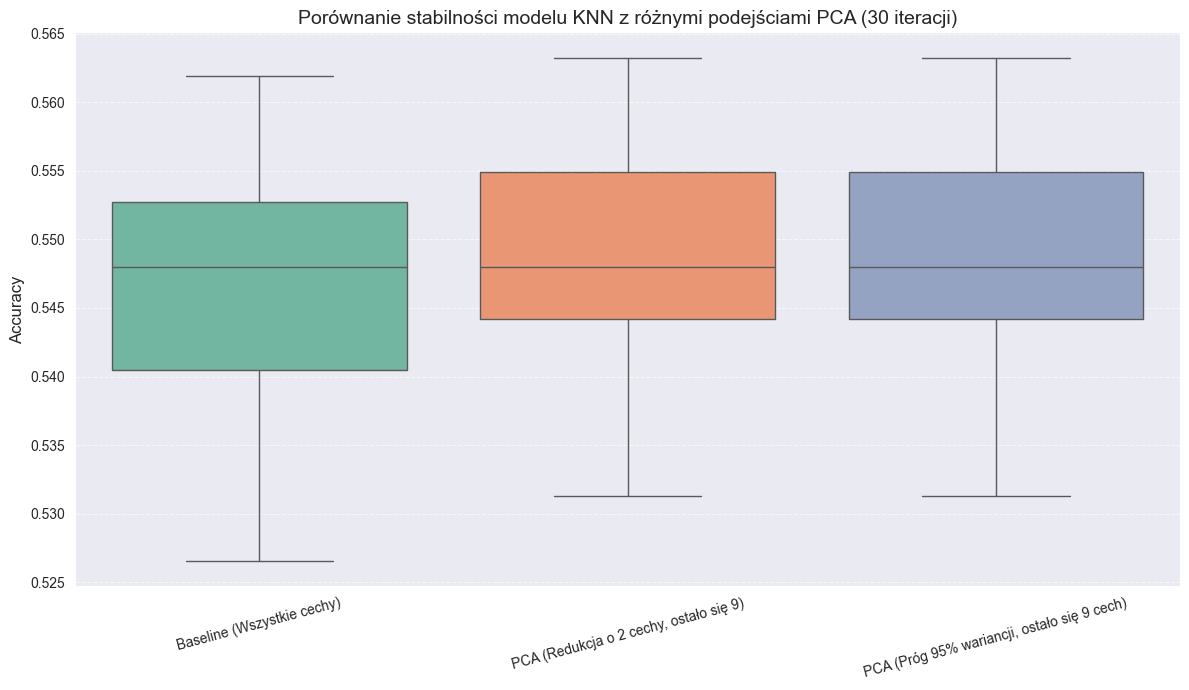

In [6]:
plt.figure(figsize=(12, 7))
sns.boxplot(data=results_df, palette='Set2')
plt.title(f'Porównanie stabilności modelu KNN z różnymi podejściami PCA ({n_experiments} iteracji)', fontsize=14)
plt.ylabel('Accuracy', fontsize=12)
plt.xticks(rotation=15)
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()